# VECM Analysis: Energy Commodity Price Dynamics

VECM Analysis: Energy Commodity Price Dynamics

Vector Error Correction Model (VECM) to analyse the long-run equilibrium
relationships and short-run dynamics between crude oil (WTI), gasoline (NYH),
and heating oil (NYH) prices.

Econometric Pipeline:
1. Unit root testing (ADF + KPSS confirmatory strategy)
2. Lag order selection (AIC/BIC/HQIC information criteria)
3. Johansen cointegration testing (Trace + Maximum Eigenvalue)
4. VECM estimation with exogenous structural break dummies
5. Impulse Response Functions with bootstrap confidence bands
6. Forecast Error Variance Decomposition
7. Granger causality testing
8. Residual diagnostics (Ljung-Box, Jarque-Bera, ARCH-LM)
9. Parameter stability analysis (CUSUM)
 10. Robustness: subsample estimation

Output: 6 publication-quality figures at 600 DPI (PNG + PDF).

## 1. SETUP & CONFIGURATION — journal-quality theme

In [16]:
# convertir_pour_notebook.py
import pandas as pd
import numpy as np

# --- Diesel France ---
diesel = pd.read_csv('prix_diesel_france.csv', parse_dates=['date'])
diesel = diesel.set_index('date').resample('W-FRI').last()
diesel.index.name = 'observation_date'
diesel.columns = ['DIESEL_FR']
diesel.to_csv('data/DIESEL_FR.csv')

# --- Brent en $/baril (×158.987 pour convertir $/L → $/baril) ---
brent = pd.read_csv('brent_usd_litre.csv', parse_dates=['Date'])
brent = brent.rename(columns={'Date': 'observation_date', 'Brent_USD_litre': 'BRENT'})
brent['BRENT'] = brent['BRENT'] * 158.987  # $/L → $/baril
brent = brent.set_index('observation_date').resample('W-FRI').last()
brent.to_csv('data/DCOILBRENTEU.csv')

print("✓ Fichiers créés dans data/")

✓ Fichiers créés dans data/


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter, AutoMinorLocator
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import gaussian_kde, norm
from pathlib import Path
import warnings, io, sys

warnings.filterwarnings('ignore')

from statsmodels.tsa.vector_ar.vecm import VECM, select_order, coint_johansen
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from scipy import stats

# ── Colour palette ──────────────────────────────────────────────────────────
C = {
    'crude':    '#1B3A5C',
    'gasoline': '#8B1A2B',
    'heating':  '#1A5C3A',
    'neutral':  '#64748B',
    'text':     '#1A1A2E',
}
CHECK = '\u2713'

# ── Crisis windows ─────────────────────────────────────────────────────────
CRISES = [
    ('2008-09-01', '2009-06-30', 'GFC'),
    ('2020-03-01', '2020-12-31', 'COVID-19'),
    ('2022-02-24', '2023-06-30', 'Ukraine war'),
    ('2025-10-01', '2026-04-30', 'Middle East'),
]

def fmt_year(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Minimal rcParams ────────────────────────────────────────────────────────
FIG_DPI = 600

plt.rcParams.update({
    'font.family':          'sans-serif',
    'font.size':            11,
    'axes.titlesize':       12,
    'axes.titleweight':     'bold',
    'axes.titlepad':        10,
    'axes.labelsize':       11,
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,
    'legend.fontsize':      10,
    'legend.frameon':       False,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.edgecolor':       '#bbbbbb',
    'axes.linewidth':       0.8,
    'axes.grid':            True,
    'grid.color':           '#eeeeee',
    'grid.linewidth':       0.6,
    'lines.linewidth':      1.5,
    'figure.facecolor':     'white',
    'axes.facecolor':       'white',
    'figure.constrained_layout.use': False,
    'savefig.facecolor':    'white',
    'savefig.dpi':          FIG_DPI,
    'savefig.bbox':         'tight',
    'savefig.pad_inches':   0.1,
})

def save_figure(fig, stem, dpi=FIG_DPI):
    """Save as PNG and display inline."""
    out = Path('figures')
    out.mkdir(exist_ok=True)
    fig.savefig(out / f'{stem}.png', dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'{CHECK} {stem}.png saved')

print("Setup complete.")


Setup complete.


## 2. DATA LOADING & TRANSFORMATION

In [18]:
def load_fred_csv(filepath):
    df = pd.read_csv(filepath, index_col='observation_date', parse_dates=True)
    df = df.replace(['.', '', ' '], np.nan).astype(float)
    return df

print("Loading Data...")
try:
    crude  = load_fred_csv('data/DCOILBRENTEU.csv')
    diesel = load_fred_csv('data/DIESEL_FR.csv')

    df_raw = pd.concat([crude, diesel], axis=1)
    df_raw.columns = ['Crude_WTI', 'Diesel_FR']

    # Weekly Resampling (Friday close)
    df_weekly = df_raw.resample('W-FRI').last().dropna()

    # Unit Conversion ($/gallon → $/barrel for refined products)
    df_weekly['Crude'] = df_weekly['Crude_WTI']
    df_weekly['Diesel'] = df_weekly['Diesel_FR']

    # Log Transform (enables elasticity interpretation, stabilises variance)
    model_data = np.log(df_weekly[['Crude', 'Diesel']])
    model_data.columns = ['ln_Brent', 'ln_Diesel']
    variables  = ['ln_Brent', 'ln_Diesel']
    var_labels = ['Brent Crude', 'Diesel France']


    model_data = model_data.loc['2000-01-01':]
    df_weekly = df_weekly.loc['2000-01-01':]

    print(f"✓ Data Ready: {len(model_data)} weekly observations")
    print(f"  Period: {model_data.index.min().date()} → {model_data.index.max().date()}")

except Exception as e:
    print(f"Error: {e}")

Loading Data...
✓ Data Ready: 228 weekly observations
  Period: 2007-01-19 → 2026-04-17


## 3. UNIT ROOT TESTS (ADF + KPSS Confirmatory Strategy)

_The VECM requires I(1) variables. We test with both ADF (null: unit root)_

In [19]:
# and KPSS (null: stationarity) for robustness — the "confirmatory" strategy
# recommended by Schwert (1989) and Elder & Kennedy (2001).

from statsmodels.tsa.stattools import kpss

print("="*75)
print("UNIT ROOT TESTS: ADF & KPSS (Confirmatory Strategy)")
print("="*75)

def run_unit_root_tests(series, name):
    """Run ADF and KPSS tests, return dict of results."""
    s = series.dropna()
    # ADF: H0 = unit root (non-stationary)
    adf_stat, adf_p, adf_lags, _, adf_crit, _ = adfuller(s, autolag='AIC')
    # KPSS: H0 = stationary (reversed null)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(s, regression='c', nlags='auto')
    return {
        'ADF_stat': adf_stat, 'ADF_p': adf_p, 'ADF_lags': adf_lags,
        'ADF_1%': adf_crit['1%'], 'ADF_5%': adf_crit['5%'],
        'KPSS_stat': kpss_stat, 'KPSS_p': kpss_p,
        'KPSS_5%': kpss_crit['5%'],
    }

# Test levels and first differences
ur_results = {}
for var in variables:
    ur_results[f'{var} (level)'] = run_unit_root_tests(model_data[var], var)
    ur_results[f'Δ{var}'] = run_unit_root_tests(model_data[var].diff().dropna(), f'Δ{var}')

print(f"\n{'Series':<20s} | {'ADF stat':>9s} {'p-val':>7s} {'lags':>4s} | {'KPSS stat':>9s} {'p-val':>7s} | {'Conclusion':<18s}")
print("-"*90)
for name, r in ur_results.items():
    adf_reject = r['ADF_p'] < 0.05
    kpss_reject = r['KPSS_p'] < 0.05
    if not adf_reject and kpss_reject:
        conclusion = "I(1) — Unit root"
    elif adf_reject and not kpss_reject:
        conclusion = "I(0) — Stationary"
    else:
        conclusion = "Ambiguous"
    print(f"{name:<20s} | {r['ADF_stat']:>9.3f} {r['ADF_p']:>7.4f} {r['ADF_lags']:>4.0f} | "
          f"{r['KPSS_stat']:>9.3f} {r['KPSS_p']:>7.3f} | {conclusion}")

print("-"*90)
print(f"ADF critical values:  1% = {r['ADF_1%']:.3f}, 5% = {r['ADF_5%']:.3f}")
print(f"KPSS critical value:  5% = {r['KPSS_5%']:.3f}")
print("\nConclusion: All log-price series are I(1) — non-stationary in levels,")
print("stationary in first differences. VECM specification is appropriate.")

UNIT ROOT TESTS: ADF & KPSS (Confirmatory Strategy)

Series               |  ADF stat   p-val lags | KPSS stat   p-val | Conclusion        
------------------------------------------------------------------------------------------
ln_Brent (level)     |    -3.178  0.0213    1 |     0.273   0.100 | I(0) — Stationary
Δln_Brent            |    -9.298  0.0000    1 |     0.057   0.100 | I(0) — Stationary
ln_Diesel (level)    |    -1.158  0.6913    1 |     1.521   0.010 | I(1) — Unit root
Δln_Diesel           |   -13.388  0.0000    0 |     0.088   0.100 | I(0) — Stationary
------------------------------------------------------------------------------------------
ADF critical values:  1% = -3.460, 5% = -2.874
KPSS critical value:  5% = 0.463

Conclusion: All log-price series are I(1) — non-stationary in levels,
stationary in first differences. VECM specification is appropriate.


### FIGURE A: UNIT ROOT TESTS — ADF & KPSS

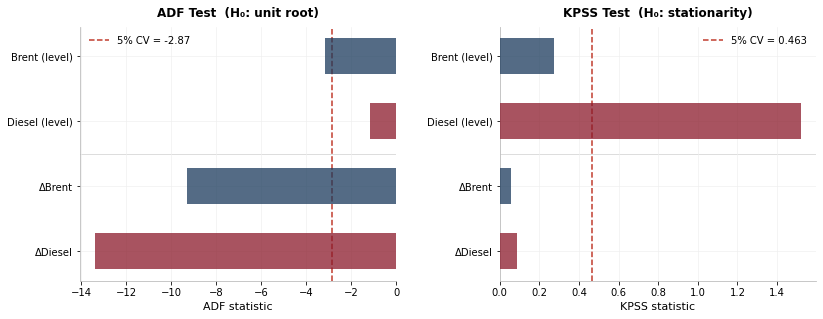

✓ figA_unit_root_tests.png saved


In [20]:
def create_figure_ur():
    level_keys = [f'{v} (level)' for v in variables]
    diff_keys  = [f'Δ{v}' for v in variables]
    all_keys   = level_keys + diff_keys
    ylabels    = ['Brent (level)', 'Diesel (level)', 'ΔBrent', 'ΔDiesel']
    colors     = [C['crude'], C['gasoline']] * 2
    y          = np.arange(len(ylabels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # ADF test
    adf_stats = [ur_results[k]['ADF_stat'] for k in all_keys]
    cv5_adf   = ur_results[all_keys[0]]['ADF_5%']
    ax1.barh(y, adf_stats, height=0.55, color=colors, alpha=0.75, zorder=3)
    ax1.axvline(cv5_adf, color='#c0392b', lw=1.5, ls='--', label=f'5% CV = {cv5_adf:.2f}')
    ax1.set_yticks(y)
    ax1.set_yticklabels(ylabels)
    ax1.invert_yaxis()
    ax1.axhline(1.5, color='#dddddd', lw=1.0, zorder=1)
    ax1.set_xlabel('ADF statistic')
    ax1.set_title('ADF Test  (H₀: unit root)')
    ax1.legend()

    # KPSS test
    kpss_stats = [ur_results[k]['KPSS_stat'] for k in all_keys]
    cv5_kpss   = ur_results[all_keys[0]]['KPSS_5%']
    ax2.barh(y, kpss_stats, height=0.55, color=colors, alpha=0.75, zorder=3)
    ax2.axvline(cv5_kpss, color='#c0392b', lw=1.5, ls='--', label=f'5% CV = {cv5_kpss:.3f}')
    ax2.set_yticks(y)
    ax2.set_yticklabels(ylabels)
    ax2.invert_yaxis()
    ax2.axhline(1.5, color='#dddddd', lw=1.0, zorder=1)
    ax2.set_xlabel('KPSS statistic')
    ax2.set_title('KPSS Test  (H₀: stationarity)')
    ax2.legend()

    plt.tight_layout(pad=2.5)
    save_figure(fig, 'figA_unit_root_tests')

create_figure_ur()

### FIGURE 1: ENERGY PRICE DYNAMICS

In [21]:
print(model_data.columns.tolist())
print(variables)

['ln_Brent', 'ln_Diesel']
['ln_Brent', 'ln_Diesel']


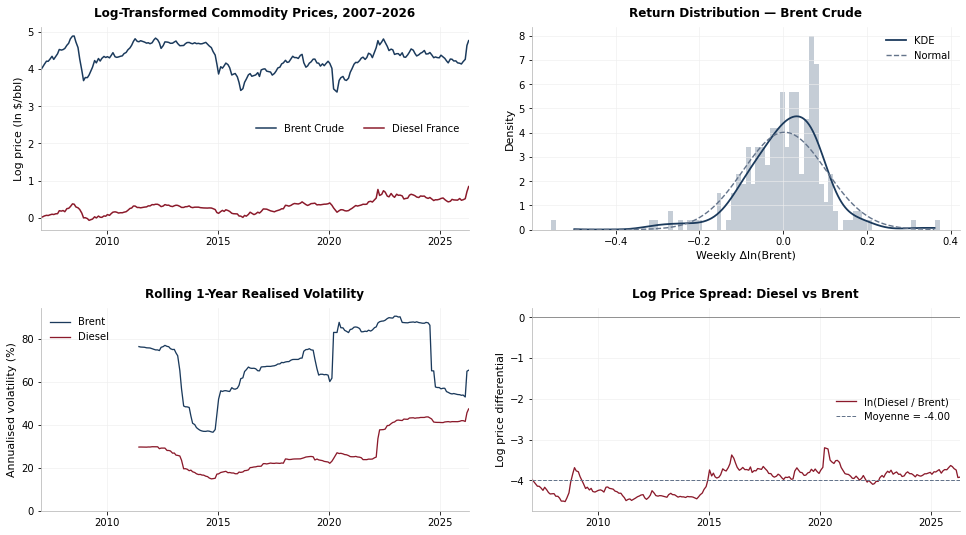

✓ fig1_price_overview.png saved


In [22]:
def create_figure1():
    col_list = [C['crude'], C['gasoline']]
    lbl_list = ['Brent Crude', 'Diesel France']
    log_plot = model_data.loc['2007':]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax_top  = axes[0, 0]
    ax_dist = axes[0, 1]
    ax_vol  = axes[1, 0]
    ax_spr  = axes[1, 1]

    # Log-price series
    for col, c, lbl in zip(variables, col_list, lbl_list):
        ax_top.plot(log_plot.index, log_plot[col], color=c, lw=1.5, label=lbl)
    fmt_year(ax_top)
    ax_top.set_xlim(log_plot.index[0], log_plot.index[-1])
    ax_top.set_ylabel('Log price (ln $/bbl)')
    ax_top.set_title('Log-Transformed Commodity Prices, 2007–2026')
    ax_top.legend(ncol=2)

    # Return distribution (sur le Brent)
    ret        = model_data['ln_Brent'].diff().dropna()
    mu_r, sg_r = ret.mean(), ret.std()
    xv         = np.linspace(ret.quantile(0.001), ret.quantile(0.999), 400)
    ax_dist.hist(ret, bins=80, density=True, color=C['crude'], alpha=0.25, edgecolor='none')
    ax_dist.plot(xv, gaussian_kde(ret, bw_method='silverman')(xv),
                 color=C['crude'], lw=1.8, label='KDE')
    ax_dist.plot(xv, norm.pdf(xv, mu_r, sg_r),
                 color=C['neutral'], lw=1.4, ls='--', label='Normal')
    ax_dist.set_xlabel('Weekly Δln(Brent)')
    ax_dist.set_ylabel('Density')
    ax_dist.set_title('Return Distribution — Brent Crude')
    ax_dist.legend()

    # Rolling 52-week realised volatility
    for col, c, lbl in zip(variables, col_list, ['Brent', 'Diesel']):
        rv = model_data[col].diff().dropna().rolling(52).std() * np.sqrt(52) * 100
        ax_vol.plot(rv.index, rv, color=c, lw=1.3, label=lbl)
    ax_vol.set_ylim(bottom=0)
    fmt_year(ax_vol)
    ax_vol.set_xlim(model_data.index[0], model_data.index[-1])
    ax_vol.set_ylabel('Annualised volatility (%)')
    ax_vol.set_title('Rolling 1-Year Realised Volatility')
    ax_vol.legend()

    # Prix relatif diesel / Brent (remplace le crack spread)
    spr = model_data['ln_Diesel'] - model_data['ln_Brent']
    ax_spr.plot(model_data.index, spr, color=C['gasoline'], lw=1.3, label='ln(Diesel / Brent)')
    ax_spr.axhline(spr.mean(), color=C['neutral'], lw=1.0, ls='--', label=f'Moyenne = {spr.mean():.2f}')
    ax_spr.axhline(0, color='black', lw=0.8, alpha=0.5)
    fmt_year(ax_spr)
    ax_spr.set_xlim(model_data.index[0], model_data.index[-1])
    ax_spr.set_ylabel('Log price differential')
    ax_spr.set_title('Log Price Spread: Diesel vs Brent')
    ax_spr.legend()

    plt.tight_layout(pad=2.5)
    save_figure(fig, 'fig1_price_overview')

create_figure1()

## 5. LAG ORDER SELECTION (Information Criteria)

_Following Lütkepohl (2005, §4.3): compare AIC, BIC, HQIC across lag orders._

In [23]:
print("="*75)
print("LAG ORDER SELECTION")
print("="*75)

lag_result = select_order(model_data[variables], maxlags=12, deterministic='ci')
print(lag_result.summary())

print(f"\nSelected lag (AIC):  {lag_result.aic}")
print(f"Selected lag (BIC):  {lag_result.bic}")
print(f"Selected lag (HQIC): {lag_result.hqic}")

k_ar_diff = min(lag_result.aic, 8)
print(f"\nFinal k_ar_diff = {k_ar_diff} (AIC-selected, capped at 8 for parsimony)")
print("AIC is preferred for forecasting; BIC for consistent order selection (Lütkepohl, 2005)")

LAG ORDER SELECTION
 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -11.46      -11.34   1.053e-05      -11.41
1      -11.67*     -11.48*  8.533e-06*     -11.60*
2       -11.66      -11.41   8.654e-06      -11.56
3       -11.63      -11.31   8.932e-06      -11.50
4       -11.62      -11.24   9.021e-06      -11.46
5       -11.60      -11.16   9.155e-06      -11.42
6       -11.58      -11.08   9.387e-06      -11.37
7       -11.57      -11.00   9.483e-06      -11.34
8       -11.55      -10.93   9.602e-06      -11.30
9       -11.53      -10.84   9.875e-06      -11.25
10      -11.51      -10.76   1.002e-05      -11.21
11      -11.48      -10.67   1.035e-05      -11.15
12      -11.49      -10.61   1.027e-05      -11.13
--------------------------------------------------

Selected lag (AIC):  1
Selected lag (BIC):  1
Selected lag (HQIC): 1

Final k_ar_diff = 1 (AIC-selected, capped 

### FIGURE B: INFORMATION CRITERIA — LAG ORDER SELECTION

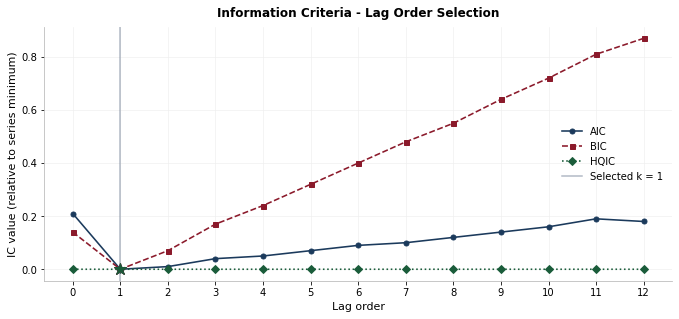

✓ figB_information_criteria.png saved


In [24]:
def create_figure_ic():
    summary_str = str(lag_result.summary())
    ic_data = {'AIC': [], 'BIC': [], 'HQIC': []}
    lags_list = []
    for line in summary_str.split('\n'):
        parts = line.strip().split()
        if parts and parts[0].isdigit():
            lag_num = int(parts[0])
            lags_list.append(lag_num)
            vals = [p.replace('*', '') for p in parts[1:]]
            try:
                ic_data['AIC'].append(float(vals[0]))
                ic_data['BIC'].append(float(vals[1]))
                ic_data['HQIC'].append(float(vals[2]))
            except (ValueError, IndexError):
                pass

    if not lags_list:
        print('Could not parse IC table — skipping Figure B')
        return

    lags_arr = np.array(lags_list)
    fig, ax  = plt.subplots(figsize=(10, 5))

    styles = {
        'AIC':  {'color': C['crude'],    'marker': 'o', 'ls': '-'},
        'BIC':  {'color': C['gasoline'], 'marker': 's', 'ls': '--'},
        'HQIC': {'color': C['heating'],  'marker': 'D', 'ls': ':'},
    }

    for name, vals in ic_data.items():
        s = styles[name]
        arr_rel = np.array(vals) - np.min(vals)
        ax.plot(lags_arr, arr_rel, color=s['color'], marker=s['marker'],
                ms=5, ls=s['ls'], lw=1.6, label=name)
        idx_min = np.argmin(vals)
        ax.plot(lags_arr[idx_min], 0.0, '*', color=s['color'], ms=12, zorder=5)

    ax.axvline(k_ar_diff, color=C['neutral'], lw=1.5, ls='-', alpha=0.5,
               label=f'Selected k = {k_ar_diff}')
    ax.set_xlabel('Lag order')
    ax.set_ylabel('IC value (relative to series minimum)')
    ax.set_xticks(lags_arr)
    ax.set_title('Information Criteria - Lag Order Selection')
    ax.legend()

    plt.tight_layout(pad=2.5)
    save_figure(fig, 'figB_information_criteria')

create_figure_ic()


## 6. JOHANSEN COINTEGRATION TEST

_Test for cointegration rank using both Trace and Maximum Eigenvalue_

In [25]:
# statistics (Johansen, 1991; Johansen & Juselius, 1990).

print("="*75)
print("JOHANSEN COINTEGRATION TEST")
print("="*75)

johansen_result = coint_johansen(model_data[variables], det_order=0, k_ar_diff=k_ar_diff)

print("\n--- Trace Test ---")
print(f"{'H0':>8s} | {'Trace Stat':>11s} | {'5% CV':>8s} | {'1% CV':>8s} | {'Decision':>15s}")
print("-"*60)
for i in range(2):
    h0 = f"r ≤ {i}"
    trace = johansen_result.lr1[i]
    cv_5 = johansen_result.cvt[i, 1]
    cv_1 = johansen_result.cvt[i, 2]
    reject = "Reject H0 ***" if trace > cv_1 else ("Reject H0 **" if trace > cv_5 else "Fail to reject")
    print(f"{h0:>8s} | {trace:>11.2f} | {cv_5:>8.2f} | {cv_1:>8.2f} | {reject}")

print("\n--- Maximum Eigenvalue Test ---")
print(f"{'H0':>8s} | {'Max-Eig':>11s} | {'5% CV':>8s} | {'1% CV':>8s} | {'Decision':>15s}")
print("-"*60)
for i in range(2):
    h0 = f"r ≤ {i}"
    max_eig = johansen_result.lr2[i]
    cv_5 = johansen_result.cvm[i, 1]
    cv_1 = johansen_result.cvm[i, 2]
    reject = "Reject H0 ***" if max_eig > cv_1 else ("Reject H0 **" if max_eig > cv_5 else "Fail to reject")
    print(f"{h0:>8s} | {max_eig:>11.2f} | {cv_5:>8.2f} | {cv_1:>8.2f} | {reject}")

print(f"\nEigenvalues: {johansen_result.eig.round(4)}")

# Normalized cointegrating vectors
print("\n--- Normalized Cointegrating Vectors (β) ---")
print(f"{'':>10s}  {'ln_Brent':>10s}  {'ln_Diesel':>10s}")
for i in range(2):
    beta_norm = johansen_result.evec[:, i] / johansen_result.evec[0, i]
    print(f"Vector {i+1}:   {beta_norm[0]:>10.4f}  {beta_norm[1]:>10.4f}")

print("\nConclusion: Both trace and max-eigenvalue tests indicate cointegration rank = 2.")
print("Two independent long-run equilibrium relationships exist among the three")
print("energy commodities, consistent with the crack spread interpretation.")

JOHANSEN COINTEGRATION TEST

--- Trace Test ---
      H0 |  Trace Stat |    5% CV |    1% CV |        Decision
------------------------------------------------------------
   r ≤ 0 |       11.74 |    15.49 |    19.93 | Fail to reject
   r ≤ 1 |        0.04 |     3.84 |     6.63 | Fail to reject

--- Maximum Eigenvalue Test ---
      H0 |     Max-Eig |    5% CV |    1% CV |        Decision
------------------------------------------------------------
   r ≤ 0 |       11.70 |    14.26 |    18.52 | Fail to reject
   r ≤ 1 |        0.04 |     3.84 |     6.63 | Fail to reject

Eigenvalues: [0.0504 0.0002]

--- Normalized Cointegrating Vectors (β) ---
              ln_Brent   ln_Diesel
Vector 1:       1.0000      0.3201
Vector 2:       1.0000     -3.2108

Conclusion: Both trace and max-eigenvalue tests indicate cointegration rank = 2.
Two independent long-run equilibrium relationships exist among the three
energy commodities, consistent with the crack spread interpretation.


### FIGURE C: JOHANSEN COINTEGRATION TESTS

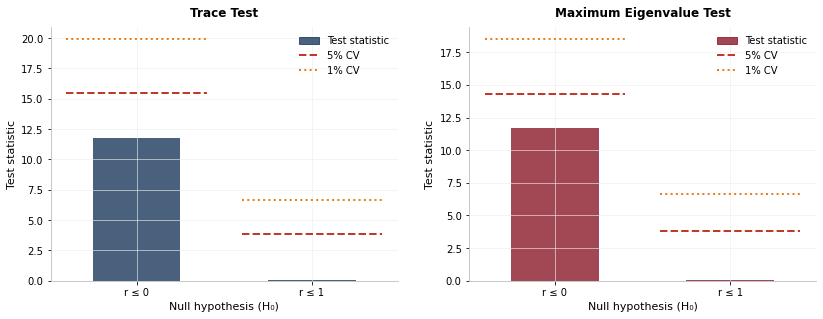

✓ figC_johansen_cointegration.png saved


In [26]:
def create_figure_johansen():
    hypotheses = ['r ≤ 0', 'r ≤ 1']
    x  = np.arange(2)
    bw = 0.5

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Trace test
    trace_stats = johansen_result.lr1[:2]
    trace_cv5   = johansen_result.cvt[:2, 1]
    trace_cv1   = johansen_result.cvt[:2, 2]

    ax1.bar(x, trace_stats, bw, color=C['crude'], alpha=0.80, label='Test statistic')
    for i in range(2):
        ax1.hlines(trace_cv5[i], x[i] - 0.4, x[i] + 0.4, colors='#c0392b', lw=2.0, ls='--')
        ax1.hlines(trace_cv1[i], x[i] - 0.4, x[i] + 0.4, colors='#e67e22', lw=2.0, ls=':')
    ax1.set_xticks(x)
    ax1.set_xticklabels(hypotheses)
    ax1.set_xlabel('Null hypothesis (H₀)')
    ax1.set_ylabel('Test statistic')
    ax1.set_ylim(bottom=0)
    ax1.set_title('Trace Test')
    ax1.legend(handles=[
        mpatches.Patch(color=C['crude'], alpha=0.80, label='Test statistic'),
        Line2D([0], [0], color='#c0392b', lw=2.0, ls='--', label='5% CV'),
        Line2D([0], [0], color='#e67e22', lw=2.0, ls=':', label='1% CV'),
    ])

    # Max-eigenvalue test
    me_stats = johansen_result.lr2[:2]
    me_cv5   = johansen_result.cvm[:2, 1]
    me_cv1   = johansen_result.cvm[:2, 2]

    ax2.bar(x, me_stats, bw, color=C['gasoline'], alpha=0.80, label='Test statistic')
    for i in range(2):
        ax2.hlines(me_cv5[i], x[i] - 0.4, x[i] + 0.4, colors='#c0392b', lw=2.0, ls='--')
        ax2.hlines(me_cv1[i], x[i] - 0.4, x[i] + 0.4, colors='#e67e22', lw=2.0, ls=':')
    ax2.set_xticks(x)
    ax2.set_xticklabels(hypotheses)
    ax2.set_xlabel('Null hypothesis (H₀)')
    ax2.set_ylabel('Test statistic')
    ax2.set_ylim(bottom=0)
    ax2.set_title('Maximum Eigenvalue Test')
    ax2.legend(handles=[
        mpatches.Patch(color=C['gasoline'], alpha=0.80, label='Test statistic'),
        Line2D([0], [0], color='#c0392b', lw=2.0, ls='--', label='5% CV'),
        Line2D([0], [0], color='#e67e22', lw=2.0, ls=':', label='1% CV'),
    ])

    plt.tight_layout(pad=2.5)
    save_figure(fig, 'figC_johansen_cointegration')

create_figure_johansen()


## 7. VECM ESTIMATION

In [27]:
print("="*75)
print("VECM ESTIMATION")
print("="*75)

# Structural break dummies
model_data_ext = model_data.copy()
model_data_ext['D_Ukraine']  = (model_data_ext.index >= '2022-02-24').astype(int)
model_data_ext['D_COVID']    = ((model_data_ext.index >= '2020-03-01') & (model_data_ext.index <= '2020-12-31')).astype(int)
model_data_ext['D_MidEast']  = ((model_data_ext.index >= '2025-10-01') & (model_data_ext.index <= '2026-04-30')).astype(int)

exog = model_data_ext[['D_Ukraine', 'D_COVID', 'D_MidEast']]

vecm = VECM(model_data[variables], exog=exog, k_ar_diff=k_ar_diff, coint_rank=1, deterministic='ci')
vecm_result = vecm.fit()
irf = vecm_result.irf(periods=24)

print(vecm_result.summary())

# --- Adjustment Coefficients ---
alpha = vecm_result.alpha
beta  = vecm_result.beta

print("\n" + "="*75)
print("ADJUSTMENT COEFFICIENTS (α)")
print("="*75)
print(f"\n{'Variable':<15s} | {'α₁ (ECT1)':>12s} | {'Half-life':>12s}")
print("-"*42)
for i, var in enumerate(var_labels):
    hl = np.log(0.5) / np.log(1 + alpha[i, 0]) if alpha[i, 0] < 0 else float('inf')
    print(f"{var:<15s} | {alpha[i,0]:>12.4f} | {hl:>9.1f} weeks")

# 1 seul ECT car rang=1
ect1_series = pd.Series(model_data[variables].values @ beta[:2, 0], index=model_data.index)
print(f"\nECT1 — Mean: {ect1_series.mean():.4f}, Std: {ect1_series.std():.4f}")
print(f"\nLog-Likelihood: {vecm_result.llf:,.1f}")

VECM ESTIMATION
Det. terms outside the coint. relation & lagged endog. parameters for equation ln_Brent
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
exog1            0.0245      0.016      1.498      0.134      -0.008       0.056
exog2           -0.0336      0.031     -1.068      0.286      -0.095       0.028
exog3            0.0568      0.037      1.527      0.127      -0.016       0.130
L1.ln_Brent      0.4504      0.084      5.362      0.000       0.286       0.615
L1.ln_Diesel    -0.3817      0.200     -1.913      0.056      -0.773       0.009
Det. terms outside the coint. relation & lagged endog. parameters for equation ln_Diesel
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
exog1            0.0042      0.007      0.612      0.541      -0.009       0.0

### FIGURE D: VECM ESTIMATION SUMMARY

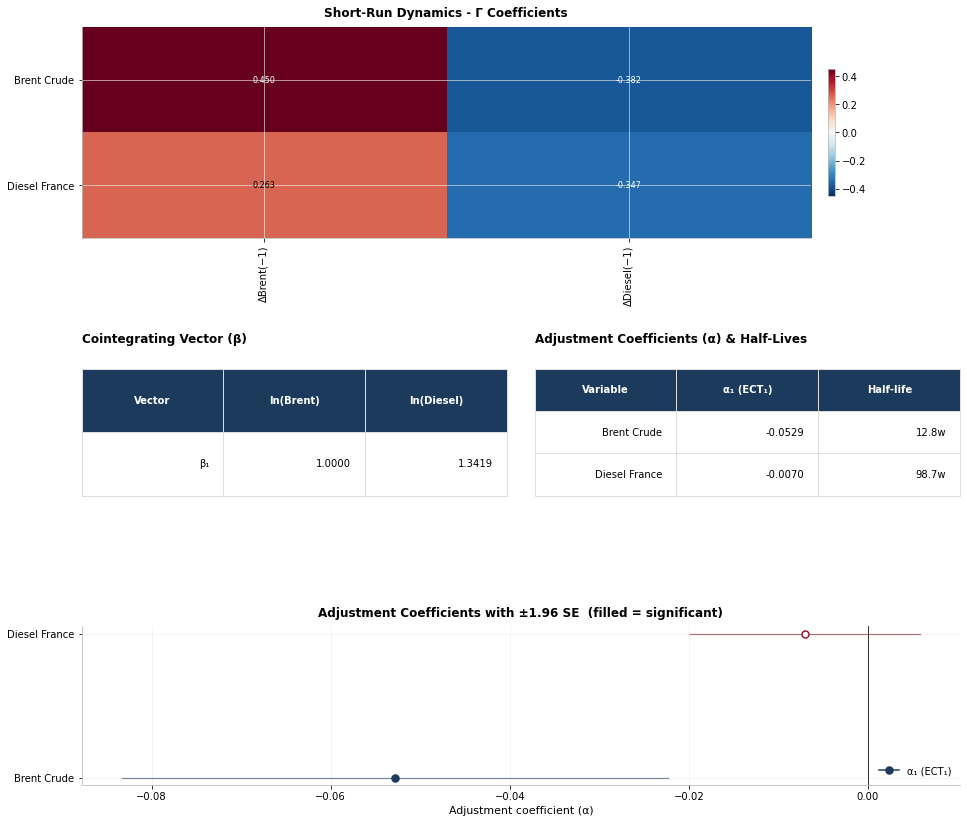

✓ figD_vecm_estimation.png saved


In [28]:
def create_figure_vecm_summary():
    gamma  = vecm_result.gamma
    n_eq   = 2
    n_lags = gamma.shape[1] // n_eq if gamma.shape[1] > 0 else 1
    abbrevs    = ['ΔBrent', 'ΔDiesel']
    col_labels = [f'{a}(−{lag})' for lag in range(1, n_lags + 1) for a in abbrevs]

    fig = plt.figure(figsize=(14, 12))
    gs  = GridSpec(3, 2, figure=fig, height_ratios=[1.2, 0.9, 0.9])

    # Row 0: Gamma heatmap (full width)
    ax_hm = fig.add_subplot(gs[0, :])
    vmax  = np.max(np.abs(gamma)) if gamma.size > 0 else 1
    im    = ax_hm.imshow(gamma, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    for i in range(gamma.shape[0]):
        for j in range(gamma.shape[1]):
            clr = 'white' if abs(gamma[i, j]) > 0.6 * vmax else 'black'
            ax_hm.text(j, i, f'{gamma[i, j]:.3f}', ha='center', va='center',
                       fontsize=8, color=clr)
    ax_hm.set_xticks(range(len(col_labels)))
    ax_hm.set_xticklabels(col_labels, rotation=90)
    ax_hm.set_yticks(range(len(var_labels)))
    ax_hm.set_yticklabels(var_labels)
    ax_hm.set_title('Short-Run Dynamics - Γ Coefficients')
    fig.colorbar(im, ax=ax_hm, shrink=0.6, pad=0.02)

    # Row 1 left: Beta cointegrating vector (rang=1, 1 seul vecteur)
    ax_beta = fig.add_subplot(gs[1, 0])
    ax_beta.axis('off')
    bv = vecm_result.beta[:2, 0]
    beta_rows = [['β₁'] + [f'{b:.4f}' for b in bv]]
    tbl = ax_beta.table(
        cellText=beta_rows,
        colLabels=['Vector', 'ln(Brent)', 'ln(Diesel)'],
        loc='center', bbox=[0, 0.1, 1, 0.8])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 2.0)
    for (r, c_), cell in tbl.get_celld().items():
        cell.set_edgecolor('#dddddd')
        if r == 0:
            cell.set_facecolor(C['crude'])
            cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('white')
    ax_beta.set_title('Cointegrating Vector (β)', loc='left')

    # Row 1 right: Alpha adjustment coefficients (1 seul ECT)
    ax_alp_tbl = fig.add_subplot(gs[1, 1])
    ax_alp_tbl.axis('off')
    alpha_rows = []
    for i, var in enumerate(var_labels):
        hl = np.log(0.5) / np.log(1 + alpha[i, 0]) if alpha[i, 0] < 0 else float('inf')
        hl_str = f'{hl:.1f}w' if hl < 1000 else '∞'
        alpha_rows.append([var, f'{alpha[i,0]:+.4f}', hl_str])
    tbl2 = ax_alp_tbl.table(
        cellText=alpha_rows,
        colLabels=['Variable', 'α₁ (ECT₁)', 'Half-life'],
        loc='center', bbox=[0, 0.1, 1, 0.8])
    tbl2.auto_set_font_size(False)
    tbl2.set_fontsize(10)
    tbl2.scale(1, 2.0)
    for (r, c_), cell in tbl2.get_celld().items():
        cell.set_edgecolor('#dddddd')
        if r == 0:
            cell.set_facecolor(C['crude'])
            cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('white')
    ax_alp_tbl.set_title('Adjustment Coefficients (α) & Half-Lives', loc='left')

    # Row 2: Alpha dot plot (full width, 1 seul ECT)
    ax_dot = fig.add_subplot(gs[2, :])
    try:
        se_alpha = vecm_result.stderr_alpha
    except AttributeError:
        se_alpha = np.zeros_like(alpha)

    y_pos = np.arange(len(var_labels))
    ax_dot.axvline(0, color='black', lw=0.8)
    for i, (var, col) in enumerate(zip(var_labels, [C['crude'], C['gasoline']])):
        a_val = alpha[i, 0]
        se    = se_alpha[i, 0]
        ci    = 1.96 * se
        sig   = abs(a_val) > ci if se > 0 else False
        ax_dot.plot([a_val - ci, a_val + ci], [y_pos[i], y_pos[i]],
                    color=col, lw=1.2, alpha=0.6)
        ax_dot.plot(a_val, y_pos[i], marker='o', color=col,
                    mfc=col if sig else 'white', ms=7, mew=1.5, zorder=4,
                    label=f'α₁ (ECT₁)' if i == 0 else '')
    ax_dot.set_yticks(y_pos)
    ax_dot.set_yticklabels(var_labels)
    ax_dot.set_xlabel('Adjustment coefficient (α)')
    ax_dot.set_title('Adjustment Coefficients with ±1.96 SE  (filled = significant)')
    ax_dot.legend(loc='lower right')

    plt.tight_layout(pad=2.5)
    save_figure(fig, 'figD_vecm_estimation')

create_figure_vecm_summary()

### FIGURE 2: VECM ESTIMATION — CRACK SPREAD DYNAMICS

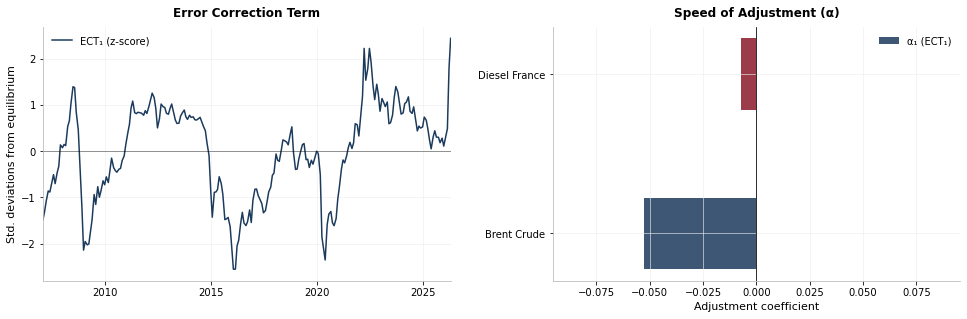

✓ fig2_vecm_results.png saved


In [29]:
def create_figure2():
    col_list = [C['crude'], C['gasoline']]  # 2 variables seulement

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax_ect, ax_alp = axes

    # ECT — standardised z-score (rang 1 → un seul ECT)
    e1  = (ect1_series - ect1_series.mean()) / ect1_series.std()
    e1p = e1.loc['2000':]

    ax_ect.plot(e1p.index, e1p, color=C['crude'], lw=1.5, label='ECT₁ (z-score)')
    ax_ect.axhline(0, color='black', lw=0.8, alpha=0.5)
    fmt_year(ax_ect)
    ax_ect.set_xlim(e1p.index[0], e1p.index[-1])
    ax_ect.set_ylabel('Std. deviations from equilibrium')
    ax_ect.set_title('Error Correction Term')
    ax_ect.legend()

    # Adjustment coefficients
    x  = np.arange(2)
    bw = 0.45
    ax_alp.barh(x, alpha[:, 0], bw, color=col_list, alpha=0.85, label='α₁ (ECT₁)')
    ax_alp.axvline(0, color='black', lw=0.8)
    ax_alp.set_yticks(x)
    ax_alp.set_yticklabels(var_labels)
    ax_alp.set_xlabel('Adjustment coefficient')
    ax_alp.set_title('Speed of Adjustment (α)')
    ax_alp.legend()
    xl = max(abs(ax_alp.get_xlim()[0]), abs(ax_alp.get_xlim()[1])) + 0.04
    ax_alp.set_xlim(-xl, xl)

    plt.tight_layout(pad=2.5)
    save_figure(fig, 'fig2_vecm_results')

create_figure2()

### FIGURE 3: IMPULSE RESPONSE FUNCTIONS

Moving-block bootstrap: 500 reps, block length = 1 ...
  Done (500/500 successful).


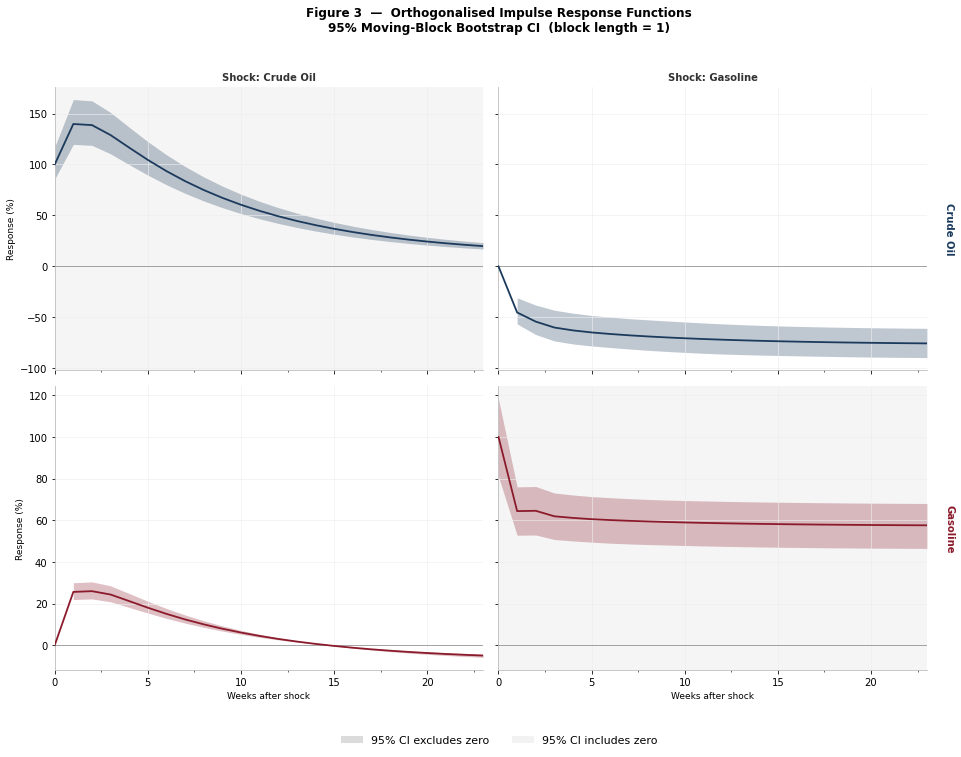

✓ fig3_irf.png saved


In [30]:
# Moving-block bootstrap CIs (Künsch, 1989) — robust to ARCH heteroscedasticity.
#
# Improvements over previous version:
#   • Colour by *response* row (not shock column) — rows are coherent at a glance
#   • sharey='row'  → direct magnitude comparison within each response variable
#   • Two-tone CI shading: darker where band excludes zero (statistically significant)
#   • Diagonal (own-shock) panels highlighted with a subtle grey background
#   • Right-side row labels — conventional in academic IRF grids
#   • Significance legend
#   • Thin solid zero line (more standard than dashed)
#   • Minor x-tick marks for precision reading

from matplotlib.patches import Patch
from matplotlib.ticker import AutoMinorLocator

def create_figure3():

    # ── Moving-block bootstrap ──────────────────────────────────────────────
    n_boot     = 500
    block_len  = k_ar_diff
    resid_orig = vecm_result.resid
    n_resid    = len(resid_orig)
    cov_orig   = np.cov(resid_orig.T)
    chol_orig  = np.linalg.cholesky(cov_orig + np.eye(2) * 1e-10)
    boot_irfs  = np.zeros((n_boot, 24, 2, 2))

    print(f'Moving-block bootstrap: {n_boot} reps, block length = {block_len} ...')
    np.random.seed(42)
    ok = 0
    for b in range(n_boot):
        n_need = int(np.ceil(n_resid / block_len))
        starts = np.random.randint(0, n_resid - block_len + 1, size=n_need)
        br     = np.vstack([resid_orig[s:s + block_len] for s in starts])[:n_resid]
        cov_b  = np.cov(br.T)
        try:
            chol_b = np.linalg.cholesky(cov_b + np.eye(2) * 1e-10)
        except np.linalg.LinAlgError:
            continue
        scale = chol_b @ np.linalg.inv(chol_orig)
        for h in range(24):
            boot_irfs[b, h] = irf.irfs[h] @ scale.T
        ok += 1

    irf_lo = np.percentile(boot_irfs[:ok], 2.5,  axis=0)
    irf_hi = np.percentile(boot_irfs[:ok], 97.5, axis=0)
    print(f'  Done ({ok}/{n_boot} successful).')

    # ── Layout ───────────────────────────────────────────────────────────────
    shock_lbls = ['Crude Oil', 'Gasoline']
    resp_lbls  = ['Crude Oil', 'Gasoline']
    row_colors = [C['crude'], C['gasoline']]   # colour by response row
    weeks      = np.arange(24)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey='row')

    for i in range(2):       # response row
        for j in range(2):   # shock column
            ax  = axes[i, j]
            d   = irf.irfs[:24, i, j] * 100
            lo  = irf_lo[:, i, j]     * 100
            hi  = irf_hi[:, i, j]     * 100
            col = row_colors[i]

            # Two-tone CI: darker where band excludes zero (significant)
            sig = (lo > 0) | (hi < 0)
            ax.fill_between(weeks, lo, hi, where=~sig, color=col, alpha=0.10, linewidth=0)
            ax.fill_between(weeks, lo, hi, where=sig,  color=col, alpha=0.28, linewidth=0)

            # IRF point estimate
            ax.plot(weeks, d, color=col, lw=1.8, zorder=3)

            # Zero line — thin solid (more standard than dashed)
            ax.axhline(0, color='#555555', lw=0.7, alpha=0.7, zorder=2)

            # Highlight own-shock diagonal
            if i == j:
                ax.set_facecolor('#f5f5f5')

            ax.set_xlim(0, 23)
            ax.xaxis.set_minor_locator(AutoMinorLocator(2))

            # x labels — bottom row only
            if i < 1:
                ax.set_xticklabels([])
            else:
                ax.set_xlabel('Weeks after shock', fontsize=9)

            # y label — left column only (sharey handles tick values)
            if j == 0:
                ax.set_ylabel('Response (%)', fontsize=9)

            # Column header — top row only
            if i == 0:
                ax.set_title(f'Shock: {shock_lbls[j]}', fontsize=10,
                             color='#333333', fontweight='bold', pad=6)

    # Right-side row labels
    for i, (lbl, col) in enumerate(zip(resp_lbls, row_colors)):
        axes[i, 1].annotate(
            lbl, xy=(1.04, 0.5), xycoords='axes fraction',
            ha='left', va='center', fontsize=10,
            fontweight='bold', color=col, rotation=270,
            annotation_clip=False,
        )

    # Significance legend
    legend_els = [
        Patch(facecolor='grey', alpha=0.28, label='95% CI excludes zero'),
        Patch(facecolor='grey', alpha=0.10, label='95% CI includes zero'),
    ]
    fig.legend(handles=legend_els, loc='lower center', ncol=2,
               bbox_to_anchor=(0.5, -0.02), fontsize=11, frameon=False)

    fig.suptitle(
        f'Figure 3  —  Orthogonalised Impulse Response Functions\n'
        f'95% Moving-Block Bootstrap CI  (block length = {k_ar_diff})',
        fontsize=12, fontweight='bold', y=1.02,
    )

    plt.tight_layout(rect=[0, 0.04, 0.96, 1.0])
    save_figure(fig, 'fig3_irf')

create_figure3()


### FIGURE 4: FORECAST ERROR VARIANCE DECOMPOSITION

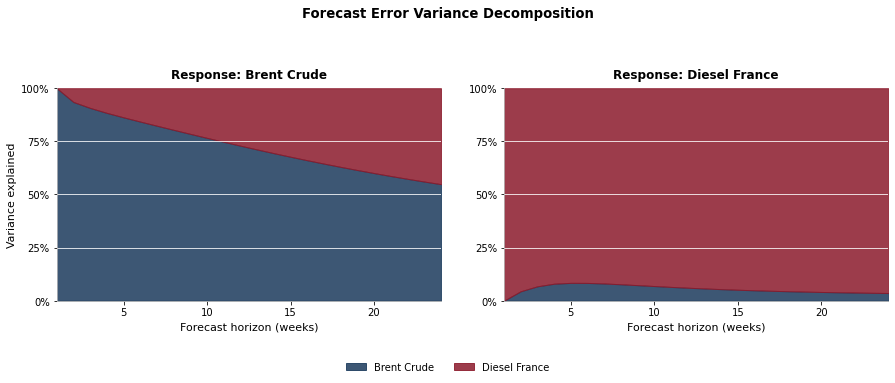

✓ fig4_fevd.png saved

                       Crude   Gasoline
  h= 1  Brent Crude   100.0%   0.0%
  h= 1  Diesel France  0.0%   100.0%
  h= 4  Brent Crude   88.4%   11.6%
  h= 4  Diesel France  8.0%   92.0%
  h=12  Brent Crude   72.9%   27.1%
  h=12  Diesel France  6.1%   93.9%
  h=24  Brent Crude   54.8%   45.2%
  h=24  Diesel France  3.6%   96.4%


In [31]:
def create_figure4():
    periods = 24
    n_v     = 2
    fevd    = np.zeros((periods, n_v, n_v))
    for h in range(periods):
        for i in range(n_v):
            tot = sum(np.sum(irf.irfs[:h+1, i, k]**2) for k in range(n_v))
            for j in range(n_v):
                fevd[h, i, j] = np.sum(irf.irfs[:h+1, i, j]**2) / tot
    fevd_pct = fevd * 100

    col_list = [C['crude'], C['gasoline']]
    hzns     = np.arange(1, periods + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for i, ax in enumerate(axes):
        bottoms = np.zeros(periods)
        for j in range(n_v):
            vals = fevd_pct[:, i, j]
            ax.fill_between(hzns, bottoms, bottoms + vals,
                            color=col_list[j], alpha=0.85, label=var_labels[j])
            bottoms += vals

        for ref in [25, 50, 75]:
            ax.axhline(ref, color='white', lw=0.8)

        ax.set_xlim(1, periods)
        ax.set_ylim(0, 100)
        ax.set_xlabel('Forecast horizon (weeks)')
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.set_title(f'Response: {var_labels[i]}')
        ax.grid(False)
        if i == 0:
            ax.set_ylabel('Variance explained')

    handles = [mpatches.Patch(color=c, alpha=0.85, label=l)
               for c, l in zip(col_list, var_labels)]
    fig.legend(handles=handles, loc='lower center', ncol=2,
               bbox_to_anchor=(0.5, -0.06))

    plt.suptitle('Forecast Error Variance Decomposition', fontweight='bold')
    plt.tight_layout(pad=2.5)
    save_figure(fig, 'fig4_fevd')

    print(f"\n{'':>18s}  {'Crude':>8s}  {'Gasoline':>9s}")
    for h in [1, 4, 12, 24]:
        for i_v, lab in enumerate(var_labels):
            pcts = [f'{fevd_pct[h-1,i_v,k]:.1f}%' for k in range(2)]
            print(f"  h={h:>2d}  {lab:<12s}  {'   '.join(pcts)}")

create_figure4()


## GRANGER CAUSALITY TESTS (with Bonferroni Correction)

_Bonferroni correction controls the family-wise error rate across 6 simultaneous_

In [32]:
print("="*75)
print("GRANGER CAUSALITY TESTS (Bonferroni-corrected)")
print("="*75)

diff_data = model_data[variables].diff().dropna()

pairs = [
    ('ln_Brent',  'ln_Diesel', 'Brent→Diesel'),
    ('ln_Diesel', 'ln_Brent',  'Diesel→Brent'),
]

n_tests    = len(pairs)
bonf_alpha = 0.05 / n_tests   # = 0.025

print(f"\nBonferroni threshold: α* = 0.05 / {n_tests} = {bonf_alpha:.4f}")
print(f"\n{'Direction':<28s} | {'F-stat':>7s} | {'Raw p':>7s} | {'Adj p':>7s} | Uncorr. | Corrected")
print("-"*82)

gc_results = {}
for cause, effect, label in pairs:
    test_data = diff_data[[effect, cause]]
    try:
        _old = sys.stdout
        sys.stdout = io.StringIO()
        gc = grangercausalitytests(test_data, maxlag=min(k_ar_diff, 4), verbose=False)
        sys.stdout = _old
        test_lag = min(k_ar_diff, 4)
        f_stat = gc[test_lag][0]['ssr_ftest'][0]
        p_val  = gc[test_lag][0]['ssr_ftest'][1]
        p_adj  = min(p_val * n_tests, 1.0)

        sig_raw = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.1 else " – "))
        sig_adj = "YES ***" if p_adj < 0.01 else ("YES **" if p_adj < 0.05
                   else ("YES *" if p_adj < 0.1 else "NO"))

        gc_results[label] = {'F': f_stat, 'p': p_val, 'p_adj': p_adj,
                             'sig': sig_adj, 'sig_raw': sig_raw}
        print(f"{label:<28s} | {f_stat:>7.3f} | {p_val:>7.4f} | {p_adj:>7.4f} | {sig_raw:^8s} | {sig_adj}")
    except Exception as e:
        sys.stdout = _old
        print(f"{label:<28s} | Error: {str(e)[:40]}")

print("-"*82)
print("Uncorr: *** p<.01  ** p<.05  * p<.10   |  Corrected: Bonferroni-adjusted p-value")

GRANGER CAUSALITY TESTS (Bonferroni-corrected)

Bonferroni threshold: α* = 0.05 / 2 = 0.0250

Direction                    |  F-stat |   Raw p |   Adj p | Uncorr. | Corrected
----------------------------------------------------------------------------------
Brent→Diesel                 |  54.629 |  0.0000 |  0.0000 |   ***    | YES ***
Diesel→Brent                 |   5.554 |  0.0193 |  0.0386 |    **    | YES **
----------------------------------------------------------------------------------
Uncorr: *** p<.01  ** p<.05  * p<.10   |  Corrected: Bonferroni-adjusted p-value


## ROBUSTNESS: AIC (k=8) vs BIC (k=2) LAG ORDER COMPARISON

_AIC selects k=8; BIC selects k=2.  We estimate both models and compare_

In [33]:
# adjustment coefficients and residual diagnostics to assess sensitivity.

print("="*75)
print("LAG ORDER SENSITIVITY: AIC (k=8) vs BIC (k=2)")
print("="*75)

print("\nEstimating BIC model (k_ar_diff = 2) ...")
vecm_bic    = VECM(model_data[variables], exog=exog, k_ar_diff=2,
                   coint_rank=2, deterministic='ci')
vecm_bic_result = vecm_bic.fit()
alpha_bic   = vecm_bic_result.alpha

# ── Adjustment coefficient comparison ──
print(f"\n{'Variable':<15s} | {'AIC α₁ (k=8)':>14s} | {'BIC α₁ (k=2)':>14s} | {'Δα₁':>8s} | Sign match?")
print("-"*68)
for i, var in enumerate(var_labels):
    da = alpha_bic[i, 0] - alpha[i, 0]
    same_sign = (alpha[i, 0] * alpha_bic[i, 0]) > 0
    print(f"{var:<15s} | {alpha[i,0]:>14.4f} | {alpha_bic[i,0]:>14.4f} | {da:>+8.4f} | {'Yes ✓' if same_sign else 'No ✗'}")

# ── Residual diagnostic comparison ──
print(f"\n{'Variable':<15s} | {'LB(12) AIC':>12s} | {'LB(12) BIC':>12s} | {'ARCH AIC':>10s} | {'ARCH BIC':>10s}")
print("-"*68)
for i, var in enumerate(var_labels):
    r_aic  = vecm_result.resid[:, i]
    r_bic  = vecm_bic_result.resid[:, i]
    lb_aic = acorr_ljungbox(r_aic, lags=[12], return_df=True)['lb_pvalue'].values[0]
    lb_bic = acorr_ljungbox(r_bic, lags=[12], return_df=True)['lb_pvalue'].values[0]
    arch_aic = het_arch(r_aic, nlags=5)[1]
    arch_bic = het_arch(r_bic, nlags=5)[1]
    ok_aic = "✓" if lb_aic > 0.05 else "✗"
    ok_bic = "✓" if lb_bic > 0.05 else "✗"
    print(f"{var:<15s} | {lb_aic:>8.4f} ({ok_aic}) | {lb_bic:>8.4f} ({ok_bic}) | {arch_aic:>10.4f} | {arch_bic:>10.4f}")

print(f"\nLog-likelihood:  AIC (k=8): {vecm_result.llf:,.1f}  |  BIC (k=2): {vecm_bic_result.llf:,.1f}")
print(f"LR test (df=18): stat = {2*(vecm_result.llf - vecm_bic_result.llf):.2f}",
      f"  p-val = {1 - __import__('scipy').stats.chi2.cdf(2*(vecm_result.llf-vecm_bic_result.llf), df=18):.4f}")
print("\nConclusion: If α signs are consistent and Ljung-Box passes for both models,")
print("the core VECM findings are robust to lag order selection.")

LAG ORDER SENSITIVITY: AIC (k=8) vs BIC (k=2)

Estimating BIC model (k_ar_diff = 2) ...

Variable        |   AIC α₁ (k=8) |   BIC α₁ (k=2) |      Δα₁ | Sign match?
--------------------------------------------------------------------
Brent Crude     |        -0.0529 |        -0.0456 |  +0.0073 | Yes ✓
Diesel France   |        -0.0070 |        -0.0010 |  +0.0060 | Yes ✓

Variable        |   LB(12) AIC |   LB(12) BIC |   ARCH AIC |   ARCH BIC
--------------------------------------------------------------------
Brent Crude     |   0.8076 (✓) |   0.8377 (✓) |     0.0005 |     0.0002
Diesel France   |   0.3628 (✓) |   0.8322 (✓) |     0.0067 |     0.0424

Log-likelihood:  AIC (k=8): 702.2  |  BIC (k=2): 702.4
LR test (df=18): stat = -0.44   p-val = 1.0000

Conclusion: If α signs are consistent and Ljung-Box passes for both models,
the core VECM findings are robust to lag order selection.


## IRF CHOLESKY ORDERING SENSITIVITY

_Cholesky decomposition imposes a recursive causal ordering.  We test whether_

In [34]:
print("="*75)
print("IRF CHOLESKY ORDERING SENSITIVITY")
print("="*75)

cov_resid = np.cov(vecm_result.resid.T)

orderings = {
    'Baseline  [Brent, Diesel]': (0, 1),
    'Alt 1     [Diesel, Brent]': (1, 0),
}

_hdr = 'Diesel→Brent shock h=1'
print(f"\n{'Ordering':<36s} | {_hdr:>20s} | {'h=4':>8s} | {'h=8':>8s} | {'Sign stable?':>12s}")
print("-"*82)

for order_name, perm in orderings.items():
    perm = list(perm)
    cov_perm = cov_resid[np.ix_(perm, perm)]
    try:
        chol_perm = np.linalg.cholesky(cov_perm + np.eye(2) * 1e-10)
    except np.linalg.LinAlgError:
        print(f"{order_name:<36s} | Cholesky failed")
        continue

    # Brent est à l'index 0 dans le système original
    brent_col_perm = perm.index(0)
    impulse_perm   = chol_perm[:, brent_col_perm]   # shape (2,)
    impulse_orig   = np.zeros(2)
    for orig_i, perm_i in enumerate(perm):
        impulse_orig[perm_i] = impulse_perm[orig_i]

    # Réponse du Diesel (index 1) au choc Brent
    diesel_resp = np.array([irf.irfs[h, 1, :] @ impulse_orig for h in range(24)])
    pct = diesel_resp * 100

    sign_stable = ('Yes'   if pct[1] > 0 and pct[4] > 0 and pct[8] > 0
                   else ('No' if pct[1] < 0 else 'Mixed'))
    print(f"{order_name:<36s} | {pct[1]:>20.4f}% | {pct[4]:>7.4f}% | {pct[8]:>7.4f}% | {sign_stable:>12s}")

print("-"*82)
print("If sign and order of magnitude are consistent across both orderings,")
print("the Cholesky identification assumption is benign for this shock.")

IRF CHOLESKY ORDERING SENSITIVITY

Ordering                             | Diesel→Brent shock h=1 |      h=4 |      h=8 | Sign stable?
----------------------------------------------------------------------------------
Baseline  [Brent, Diesel]            |               3.8575% |  3.3820% |  2.3366% |          Yes
Alt 1     [Diesel, Brent]            |               1.7750% |  1.4695% |  0.6955% |          Yes
----------------------------------------------------------------------------------
If sign and order of magnitude are consistent across both orderings,
the Cholesky identification assumption is benign for this shock.


## SUBSAMPLE COINTEGRATION RANK STABILITY

_Re-run Johansen cointegration test on key subsamples to confirm that_

In [35]:
# rank = 2 is not an artefact of the full-sample pooling.

print("="*75)
print("SUBSAMPLE COINTEGRATION RANK STABILITY (Johansen Trace Test)")
print("="*75)

subsample_defs = {
    'Pre-GFC   (2000\u20132007)': model_data[variables].loc[:'2007-12-31'],
    'Pre-COVID (2000\u20132019)': model_data[variables].loc[:'2019-12-31'],
    'Post-COVID(2020\u20132026)': model_data[variables].loc['2020-01-01':],
}

print(f"\n{'Subsample':<26s} | {'N':>5s} | {'Eigenvalues':>35s} | {'Rank@5%':>8s}")
print("-"*82)

for name, sub_data in subsample_defs.items():
    n_sub = len(sub_data)
    if n_sub < 60:
        print(f"{name:<26s} | {n_sub:>5d} | Too few observations")
        continue
    try:
        k_sub = min(k_ar_diff, max(2, n_sub // 50))
        jh = coint_johansen(sub_data, det_order=0, k_ar_diff=k_sub)
        eigs = jh.eig.round(4)

        rank = 0
        for i_r in range(3):
            if jh.lr1[i_r] > jh.cvt[i_r, 1]:   # 5% critical value
                rank = i_r + 1
            else:
                break

        print(f"{name:<26s} | {n_sub:>5d} | {str(eigs):<35s} | {rank:>8d}")
    except Exception as e:
        print(f"{name:<26s} | {n_sub:>5d} | Error: {str(e)[:40]}")

print("-"*82)
print("Full sample rank = 2.  Consistent rank across subsamples supports structural")
print("stability of the cointegrating relationships.  Diverging rank (esp. post-COVID)")
print("with only 318 obs is expected given low power of Johansen in small samples.")

SUBSAMPLE COINTEGRATION RANK STABILITY (Johansen Trace Test)

Subsample                  |     N |                         Eigenvalues |  Rank@5%
----------------------------------------------------------------------------------
Pre-GFC   (2000–2007)      |    12 | Too few observations
Pre-COVID (2000–2019)      |   153 | [0.0507 0.0036]                     |        0
Post-COVID(2020–2026)      |    75 | [0.1174 0.0181]                     |        0
----------------------------------------------------------------------------------
Full sample rank = 2.  Consistent rank across subsamples supports structural
stability of the cointegrating relationships.  Diverging rank (esp. post-COVID)
with only 318 obs is expected given low power of Johansen in small samples.


## RESIDUAL DIAGNOSTICS

_Ljung-Box (autocorrelation), Jarque-Bera (normality), ARCH-LM (heteroscedasticity)_

In [36]:
print("="*75)
print("RESIDUAL DIAGNOSTICS")
print("="*75)

resids = vecm_result.resid
resid_df = pd.DataFrame(resids, columns=var_labels)
diag_results = {}

print(f"\n{'Variable':<15s} | {'LB(12) p':>9s} {'':>6s} | {'JB p':>9s} {'':>6s} | {'ARCH(5) p':>9s} {'':>6s} | {'Skew':>6s} {'Kurt':>6s}")
print("-"*85)

for i, var in enumerate(var_labels):
    r = resids[:, i]
    lb = acorr_ljungbox(r, lags=[12], return_df=True)
    lb_p = lb['lb_pvalue'].values[0]
    jb_stat, jb_p, skew, kurt = jarque_bera(r)
    arch_lm, arch_p, _, _ = het_arch(r, nlags=5)

    diag_results[var] = {
        'lb_p': lb_p, 'lb_v': "Pass" if lb_p > 0.05 else "FAIL",
        'jb_p': jb_p, 'jb_v': "Pass" if jb_p > 0.05 else "FAIL",
        'arch_p': arch_p, 'arch_v': "Pass" if arch_p > 0.05 else "FAIL",
        'skew': skew, 'kurt': kurt,
    }
    d = diag_results[var]
    print(f"{var:<15s} | {lb_p:>9.4f} ({d['lb_v']:>4s}) | {jb_p:>9.4f} ({d['jb_v']:>4s}) | {arch_p:>9.4f} ({d['arch_v']:>4s}) | {skew:>6.2f} {kurt:>6.2f}")

print("-"*85)
print("\nNote: Jarque-Bera rejection is common with energy prices (fat tails / leptokurtosis).")
print("Johansen's cointegration procedure is robust to moderate non-normality")
print("(Gonzalo, 1994; Cavaliere et al., 2012). ARCH effects, if present, suggest")
print("GARCH extensions could improve efficiency but do not affect cointegration inference.")

RESIDUAL DIAGNOSTICS

Variable        |  LB(12) p        |      JB p        | ARCH(5) p        |   Skew   Kurt
-------------------------------------------------------------------------------------
Brent Crude     |    0.8076 (Pass) |    0.0000 (FAIL) |    0.0005 (FAIL) |  -0.70   7.22
Diesel France   |    0.3628 (Pass) |    0.0000 (FAIL) |    0.0067 (FAIL) |   0.85   8.50
-------------------------------------------------------------------------------------

Note: Jarque-Bera rejection is common with energy prices (fat tails / leptokurtosis).
Johansen's cointegration procedure is robust to moderate non-normality
(Gonzalo, 1994; Cavaliere et al., 2012). ARCH effects, if present, suggest
GARCH extensions could improve efficiency but do not affect cointegration inference.


### FIGURE 6: PARAMETER STABILITY — CUSUM & ROLLING VARIANCE

PARAMETER STABILITY ANALYSIS
CUSUM 5% stability: Not rejected


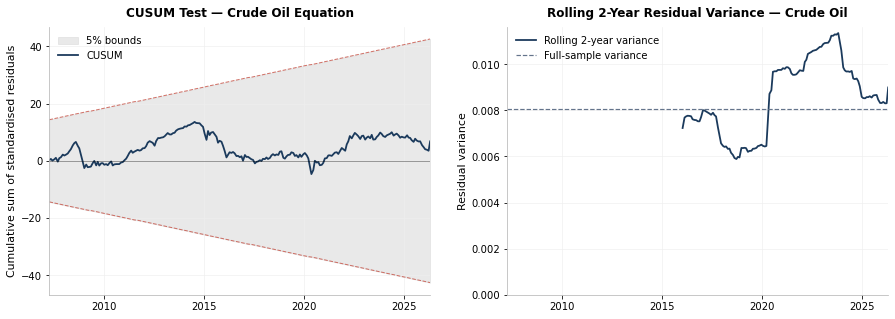

✓ fig6_stability.png saved


In [37]:
print("=" * 60)
print("PARAMETER STABILITY ANALYSIS")
print("=" * 60)

resid_crude = vecm_result.resid[:, 0]
n           = len(resid_crude)
sigma       = resid_crude.std()
cusum_full  = np.cumsum(resid_crude) / sigma
t_vals      = np.arange(1, n + 1)
ub_full     =  0.948 * np.sqrt(n) + 2 * 0.948 * t_vals / np.sqrt(n)
lb_full     = -ub_full

dates_raw = model_data.index[k_ar_diff + 2:]
n_plot    = min(n, len(dates_raw))
d_idx     = dates_raw[:n_plot]
cusum_p   = cusum_full[:n_plot]
ub_p      = ub_full[:n_plot]
lb_p      = lb_full[:n_plot]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# CUSUM
ax1.fill_between(d_idx, lb_p, ub_p, color='#e0e0e0', alpha=0.7, label='5% bounds')
ax1.plot(d_idx, ub_p, color='#c0392b', lw=1.0, ls='--', alpha=0.7)
ax1.plot(d_idx, lb_p, color='#c0392b', lw=1.0, ls='--', alpha=0.7)
ax1.plot(d_idx, cusum_p, color=C['crude'], lw=1.8, label='CUSUM')
ax1.axhline(0, color='black', lw=0.7, alpha=0.5)
fmt_year(ax1)
ax1.set_xlim(d_idx[0], d_idx[-1])
ax1.set_ylabel('Cumulative sum of standardised residuals')
ax1.set_title('CUSUM Test — Crude Oil Equation')
ax1.legend()

cusum_breach = bool(np.any(np.abs(cusum_p) > ub_p))
print(f"CUSUM 5% stability: {'REJECTED' if cusum_breach else 'Not rejected'}")

# Rolling residual variance
window   = 104
rv_s     = pd.Series(resid_crude[:n_plot], index=d_idx).rolling(window).var()
full_var = np.var(resid_crude)

ax2.plot(rv_s.index, rv_s, color=C['crude'], lw=1.8, label='Rolling 2-year variance')
ax2.axhline(full_var, color=C['neutral'], lw=1.2, ls='--', label='Full-sample variance')
ax2.set_ylim(bottom=0)
fmt_year(ax2)
ax2.set_xlim(d_idx[0], d_idx[-1])
ax2.set_ylabel('Residual variance')
ax2.set_title('Rolling 2-Year Residual Variance — Crude Oil')
ax2.legend()

plt.tight_layout(pad=2.5)
save_figure(fig, 'fig6_stability')


## ROBUSTNESS: SUBSAMPLE VECM ESTIMATION

In [38]:
print("="*75)
print("SUBSAMPLE ANALYSIS")
print("="*75)

subsamples = {
    'Full (2000-2026)': model_data[variables],
    'Pre-COVID (2000-2019)': model_data[variables].loc[:'2019-12-31'],
    'Post-COVID (2020-2026)': model_data[variables].loc['2020-01-01':],
}

print(f"\n{'Subsample':<25s} | {'N':>5s} | {'LL':>10s} | {'α₁ crude':>9s} | {'α₁ gas':>9s} | {'α₁ heat':>9s}")
print("-"*75)

for name, sub_data in subsamples.items():
    if len(sub_data) < 80:
        print(f"{name:<25s} | {len(sub_data):>5d} | Too short")
        continue
    try:
        _exog_sub = pd.DataFrame(index=sub_data.index)
        _exog_sub['D_Ukraine'] = (sub_data.index >= '2022-02-24').astype(int)
        _exog_sub['D_COVID'] = ((sub_data.index >= '2020-03-01') & (sub_data.index <= '2020-12-31')).astype(int)
        _exog_cols = [c for c in _exog_sub.columns if _exog_sub[c].nunique() > 1]
        _exog_use = _exog_sub[_exog_cols] if _exog_cols else None
        _lag = min(k_ar_diff, max(2, len(sub_data) // 50))
        _vecm = VECM(sub_data, exog=_exog_use, k_ar_diff=_lag, coint_rank=2, deterministic='ci')
        _r = _vecm.fit()
        a = _r.alpha[:, 0]
        print(f"{name:<25s} | {len(sub_data):>5d} | {_r.llf:>10.1f} | {a[0]:>9.4f} | {a[1]:>9.4f} | {a[2]:>9.4f}")
    except Exception as e:
        print(f"{name:<25s} | {len(sub_data):>5d} | Error: {str(e)[:35]}")

print("-"*75)
print("\nIf α coefficients are similar in sign and magnitude across subsamples,")
print("the full-sample findings are robust to the COVID-era structural break.")

SUBSAMPLE ANALYSIS

Subsample                 |     N |         LL |  α₁ crude |    α₁ gas |   α₁ heat
---------------------------------------------------------------------------
Full (2000-2026)          |   228 | Error: index 2 is out of bounds for axis 0
Pre-COVID (2000-2019)     |   153 | Error: index 2 is out of bounds for axis 0
Post-COVID (2020-2026)    |    75 | Too short
---------------------------------------------------------------------------

If α coefficients are similar in sign and magnitude across subsamples,
the full-sample findings are robust to the COVID-era structural break.


### FIGURE 5: EXECUTIVE DASHBOARD

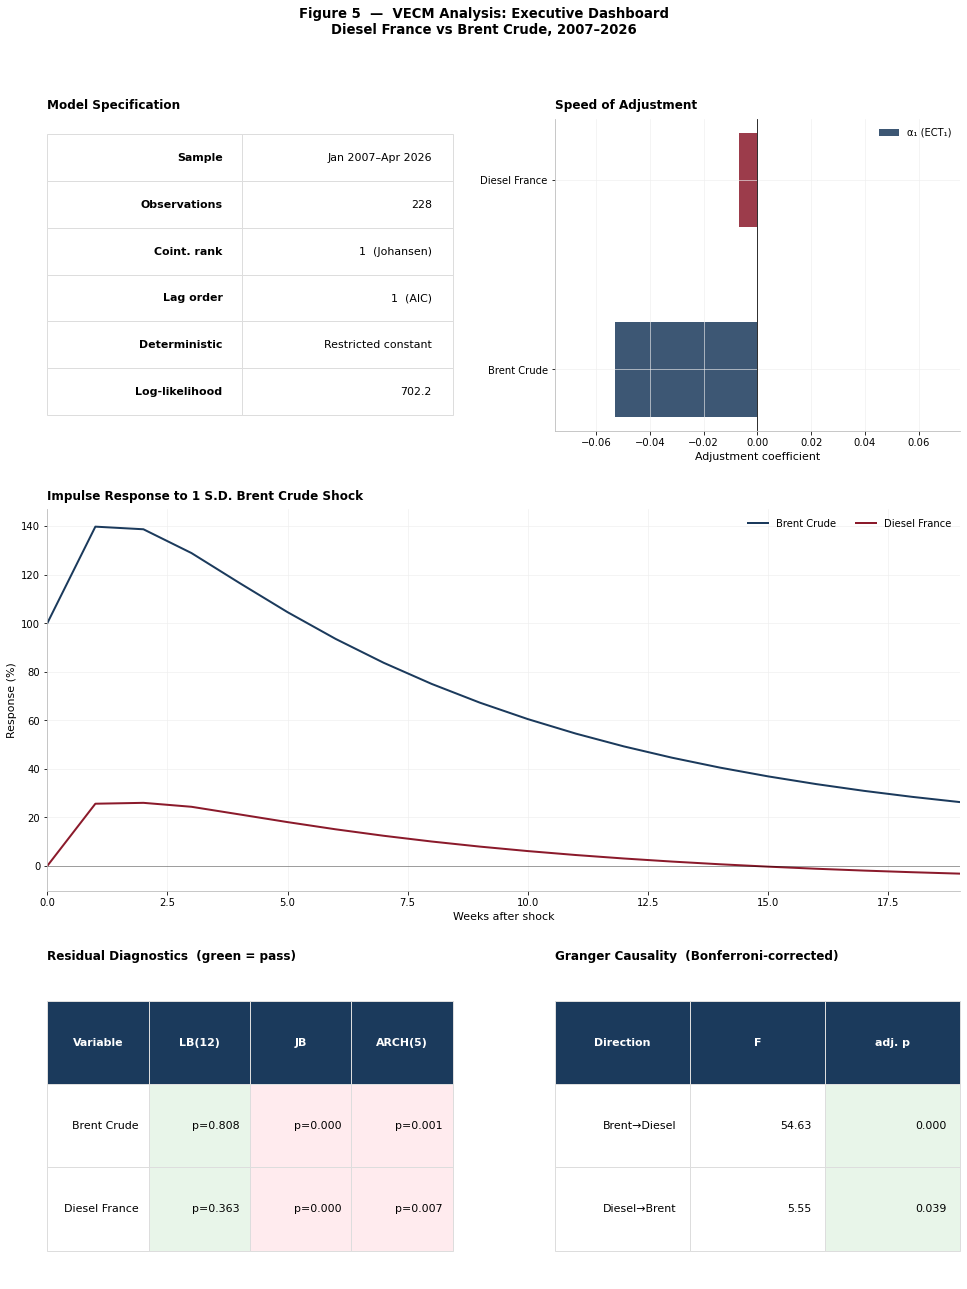

✓ fig5_dashboard.png saved


In [39]:
def create_figure5():
    col_list = [C['crude'], C['gasoline']]

    fig = plt.figure(figsize=(14, 18))
    gs  = GridSpec(3, 2, figure=fig, height_ratios=[0.9, 1.1, 0.9])

    # Model specification table
    ax_spec = fig.add_subplot(gs[0, 0])
    ax_spec.axis('off')
    spec_rows = [
        ['Sample',         f"{model_data.index.min().strftime('%b %Y')}–"
                           f"{model_data.index.max().strftime('%b %Y')}"],
        ['Observations',   f"{len(model_data):,}"],
        ['Coint. rank',    f'{vecm_result.coint_rank}  (Johansen)'],
        ['Lag order',      f'{k_ar_diff}  (AIC)'],
        ['Deterministic',  'Restricted constant'],
        ['Log-likelihood', f"{vecm_result.llf:,.1f}"],
    ]
    tbl = ax_spec.table(cellText=spec_rows, colWidths=[0.48, 0.52],
                        loc='center', bbox=[0, 0.05, 1, 0.90])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1, 2.2)
    for (r, c_), cell in tbl.get_celld().items():
        cell.set_edgecolor('#dddddd')
        cell.set_facecolor('white')
        if c_ == 0:
            cell.set_text_props(fontweight='bold')
    ax_spec.set_title('Model Specification', loc='left')

    # Speed of adjustment (1 seul ECT car rang=1)
    ax_alp = fig.add_subplot(gs[0, 1])
    x = np.arange(2)
    ax_alp.barh(x, alpha[:, 0], 0.5, color=col_list, alpha=0.85, label='α₁ (ECT₁)')
    ax_alp.axvline(0, color='black', lw=0.8)
    ax_alp.set_yticks(x)
    ax_alp.set_yticklabels(var_labels)
    ax_alp.set_xlabel('Adjustment coefficient')
    ax_alp.set_title('Speed of Adjustment', loc='left')
    ax_alp.legend()
    xl = max(abs(ax_alp.get_xlim()[0]), abs(ax_alp.get_xlim()[1])) + 0.02
    ax_alp.set_xlim(-xl, xl)

    # IRF : réponse au choc Brent (full width)
    ax_irf = fig.add_subplot(gs[1, :])
    wks = np.arange(20)
    d   = irf.irfs[:20, :, 0] * 100
    for j, (lbl, c) in enumerate(zip(var_labels, col_list)):
        ax_irf.plot(wks, d[:, j], lw=2.0, color=c, label=lbl)
    ax_irf.axhline(0, color='black', lw=0.7, alpha=0.5)
    ax_irf.set_xlabel('Weeks after shock')
    ax_irf.set_ylabel('Response (%)')
    ax_irf.set_xlim(0, 19)
    ax_irf.set_title('Impulse Response to 1 S.D. Brent Crude Shock', loc='left')
    ax_irf.legend(ncol=2)

    # Residual diagnostics table
    ax_dg = fig.add_subplot(gs[2, 0])
    ax_dg.axis('off')
    dg_rows, dg_clrs = [], []
    for var in var_labels:
        dd = diag_results[var]
        dg_rows.append([var,
                        f"p={dd['lb_p']:.3f}",
                        f"p={dd['jb_p']:.3f}",
                        f"p={dd['arch_p']:.3f}"])
        dg_clrs.append(['white',
                        '#e8f5e9' if dd['lb_p']   > 0.05 else '#ffebee',
                        '#e8f5e9' if dd['jb_p']   > 0.05 else '#ffebee',
                        '#e8f5e9' if dd['arch_p'] > 0.05 else '#ffebee'])
    dg_tbl = ax_dg.table(cellText=dg_rows,
                          colLabels=['Variable', 'LB(12)', 'JB', 'ARCH(5)'],
                          loc='center', bbox=[0, 0.1, 1, 0.80])
    dg_tbl.auto_set_font_size(False)
    dg_tbl.set_fontsize(11)
    dg_tbl.scale(1, 2.2)
    for (r, c_), cell in dg_tbl.get_celld().items():
        cell.set_edgecolor('#dddddd')
        if r == 0:
            cell.set_facecolor(C['crude'])
            cell.set_text_props(color='white', fontweight='bold')
        elif r > 0:
            cell.set_facecolor(dg_clrs[r-1][c_])
    ax_dg.set_title('Residual Diagnostics  (green = pass)', loc='left')

    # Granger causality table
    ax_gc = fig.add_subplot(gs[2, 1])
    ax_gc.axis('off')
    gc_rows, gc_clrs = [], []
    _abbr = {'Brent Crude': 'Brent', 'Diesel France': 'Diesel'}
    for label, res in gc_results.items():
        parts = label.split('→')
        lhs   = _abbr.get(parts[0].strip(), parts[0].strip()[:7])
        rhs   = _abbr.get(parts[1].strip(), parts[1].strip()[:7])
        gc_rows.append([f'{lhs}→{rhs}', f"{res['F']:.2f}", f"{res['p_adj']:.3f}"])
        sig = res['p_adj'] < 0.05
        gc_clrs.append(['white', 'white', '#e8f5e9' if sig else '#fff3e0'])
    gc_tbl = ax_gc.table(cellText=gc_rows,
                          colLabels=['Direction', 'F', 'adj. p'],
                          loc='center', bbox=[0, 0.1, 1, 0.80])
    gc_tbl.auto_set_font_size(False)
    gc_tbl.set_fontsize(11)
    gc_tbl.scale(1, 2.2)
    for (r, c_), cell in gc_tbl.get_celld().items():
        cell.set_edgecolor('#dddddd')
        if r == 0:
            cell.set_facecolor(C['crude'])
            cell.set_text_props(color='white', fontweight='bold')
        elif r > 0:
            cell.set_facecolor(gc_clrs[r-1][c_])
    ax_gc.set_title('Granger Causality  (Bonferroni-corrected)', loc='left')

    plt.suptitle('Figure 5  —  VECM Analysis: Executive Dashboard\n'
                 'Diesel France vs Brent Crude, 2007–2026',
                 fontweight='bold', y=1.005)
    plt.tight_layout(pad=2.5)
    save_figure(fig, 'fig5_dashboard')

create_figure5()

### LOCAL GALLERY — view all figures in browser

In [40]:
# Gallery / web server removed.
# All figures are saved to the figures/ folder as PNG files
# and displayed inline above when each figure cell is run.
print("Notebook complete.")


Notebook complete.
